In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

from kafka import KafkaConsumer
from kafka import KafkaProducer
from collections import deque
import json
import time
import numpy as np

from tensorflow.keras.models import load_model
import joblib

import sys, types
from json import dumps

# Kafka Consumer 초기화
TOPIC_NAME = 'DGSP-SENSOR-DATA-SM2'
KAFKA_SERVER = 'piai_kafka2.aiot.town:9092'

consumer = KafkaConsumer(
    TOPIC_NAME,
    bootstrap_servers=KAFKA_SERVER,
    value_deserializer=lambda x: json.loads(x.decode('utf-8')),
    auto_offset_reset = 'latest',
    max_poll_records = 60
)

# publish 필요 코드
m = types.ModuleType('kafka.vendor.six.moves', 'Mock module')
setattr(m, 'range', range)
sys.modules['kafka.vendor.six.moves'] = m
bootstrap_servers = ['piai_kafka2.aiot.town:9092',]

json_producer = KafkaProducer(    
    bootstrap_servers=bootstrap_servers, # 전달하고자 하는 카프카 브로커의 주소 리스트
    value_serializer=lambda x:dumps(x).encode('utf-8') # 메시지의 값 직렬화
)

# 최근 60초 데이터를 저장할 deque
buffer = deque(maxlen=60)

# 모델 로드
model = load_model("train_model.h5")

loaded_scaler = joblib.load("scaler_data")

In [2]:
import time
threshold = 0.08

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

for message in consumer:
    # 메시지 데이터 추출
    data = message.value  # JSON 데이터를 딕셔너리로 파싱

    # nan 값이 없을 때 동작
    if not any(isinstance(value, float) and np.isnan(value) for value in data.values()):
        # 현재 시간과 데이터 추가
        buffer.append(data)
    
        # 1. Convert deque to list of dictionaries
        data_list = list(buffer)
        
        # 2. Select relevant features (exclude 'Timestamp')
        features = ['Humidity', 'Temperature', 'Gas(MQ-2)', 'Gas(MQ-4)']
        
        # 3. Convert to numpy array
        data_array = np.array([[entry[feature] for feature in features] for entry in data_list])

    if len(data_array) == 60:
        # print('suzip:', data_array)
        
        # 로드한 스케일러로 변환
        scaled_data = loaded_scaler.transform(data_array)

        # print("scaled:", scaled_data)

        scaled_data = np.expand_dims(scaled_data, axis=0)
        predictions = model.predict(scaled_data, verbose = 0)
        
        # print("Predictions:", predictions)

        mae = np.mean(np.abs(scaled_data - predictions))
        # print("Mean Absolute Error (MAE):", mae)
        if mae > threshold:
            risk = 100
            state = 'abnormal'
            # print('abnormal')
        else:
            risk = (mae / threshold) * 100
            state = 'normal'
        
        publish_dict = {
            "Timestamp" : data['Timestamp'],
            "Measurement" : scaled_data.tolist(),
            "Predictions" : predictions.tolist(),
			"MAE" : mae,
            "Risk" : risk,
			"Abnormal state" : state
		}
        
        publish_result = json_producer.send('DGSP-GAS-INFERENCE-SM2', value = publish_dict)

        # print(publish_result)

KeyboardInterrupt: 

In [3]:
### 입력 값 그래프 ###

import matplotlib.pyplot as plt

# 데이터 형태 확인
print("Data Shape:", scaled_data.shape)

# 데이터 축 변환 (batch 제거)
scaled_data = scaled_data[0]  # shape becomes (11, 4)

# 각 피처(feature)를 시간(time)에 따라 시각화
features = ["Feature 1", "Feature 2", "Feature 3", "Feature 4"]
time_steps = range(scaled_data.shape[0])

# Plot
plt.figure(figsize=(10, 6))
for i in range(scaled_data.shape[1]):
    plt.plot(time_steps, scaled_data[:, i], label=features[i])

plt.xlabel("Time Steps")
plt.ylabel("Feature Values")
plt.title("Time Series Data Visualization")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'scaled_data' is not defined

Data Shape: (1, 60, 4)


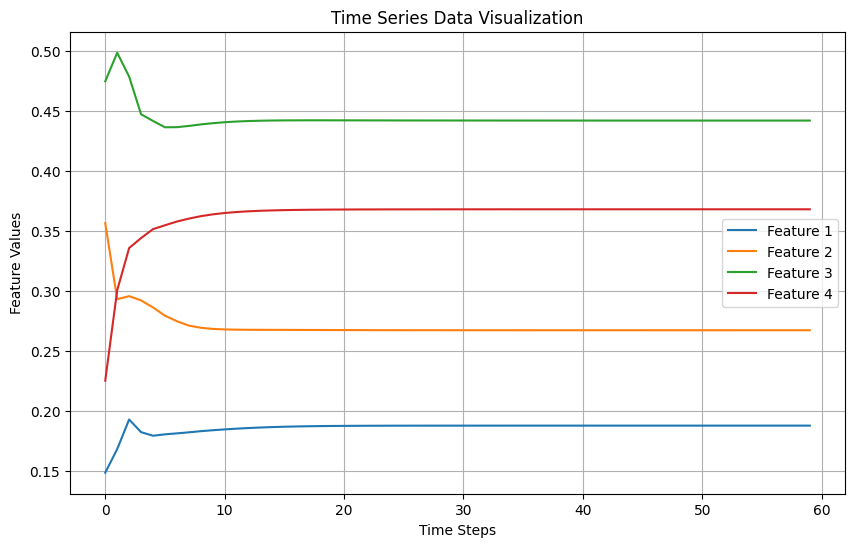

In [5]:
### 예측 값 그래프 ###

# 데이터 형태 확인
print("Data Shape:", predictions.shape)

# 데이터 축 변환 (batch 제거)
predictions = predictions[0]  # shape becomes (11, 4)

# 각 피처(feature)를 시간(time)에 따라 시각화
features = ["Feature 1", "Feature 2", "Feature 3", "Feature 4"]
time_steps = range(predictions.shape[0])

# Plot
plt.figure(figsize=(10, 6))
for i in range(predictions.shape[1]):
    plt.plot(time_steps, predictions[:, i], label=features[i])

plt.xlabel("Time Steps")
plt.ylabel("Feature Values")
plt.title("Time Series Data Visualization")
plt.legend()
plt.grid(True)
plt.show()